In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# 1. Regression analysis of insured persons over time

This notebook fits polynomial regressions to the insurance dataset, compares fit quality using $R^2$, removes a clear outlier, and then refits the models to the cleaned data before making a 1997 prediction.

## Load data and define metrics

In [ ]:
years = np.arange(1987, 1997)
x = np.arange(len(years))  # x values correspond to years since 1987

y = np.array([12400, 10900, 10000, 1050, 9500, 8900, 8000, 7800, 7600, 7200])

# Helper to compute coefficient of determination
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

## Fit polynomial models to the original dataset

In [ ]:
# Fit linear, quadratic, and cubic models to the original data
p_lin = Polynomial.fit(x, y, 1)
p_quad = Polynomial.fit(x, y, 2)
p_cubic = Polynomial.fit(x, y, 3)

# Compute predictions at the original x coordinates
y_lin = p_lin(x)
y_quad = p_quad(x)
y_cubic = p_cubic(x)

# Compute model quality using R^2
r2_lin = r2_score(y, y_lin)
r2_quad = r2_score(y, y_quad)
r2_cubic = r2_score(y, y_cubic)

original_r2 = {
    'linear': r2_lin,
    'quadratic': r2_quad,
    'cubic': r2_cubic,
}

print('Original model R^2 values:')
for name, value in original_r2.items():
    print(f'  {name.capitalize():9s}: {value:.4f}')

Original model R^2 values:
  Linear   : 0.1345
  Quadratic: 0.2534
  Cubic    : 0.3829


## Plot the original data and fitted curves

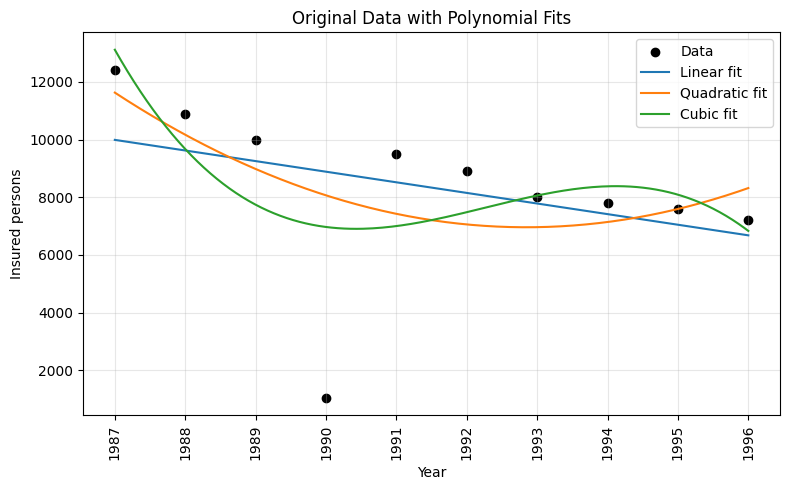

In [ ]:
# Use the same x coordinate scale when evaluating the polynomial models
xx = np.linspace(0, 9, 200)
xx_years = 1987 + xx

plt.figure(figsize=(8, 5))
plt.scatter(years, y, color='black', label='Data')
plt.plot(xx_years, p_lin(xx), label='Linear fit')
plt.plot(xx_years, p_quad(xx), label='Quadratic fit')
plt.plot(xx_years, p_cubic(xx), label='Cubic fit')
plt.title('Original Data with Polynomial Fits')
plt.xlabel('Year')
plt.ylabel('Insured persons')
plt.xticks(years, rotation='vertical')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Original Data with Fits.png')
plt.show()
plt.close()

## Remove the outlier and refit on cleaned data

In [ ]:
# Use an explicit mask to remove the obvious outlier at 1990 (value 1050)
mask = y > 5000
x_clean = x[mask]
y_clean = y[mask]
years_clean = years[mask]

# Refit models to the cleaned dataset
p_lin_c = Polynomial.fit(x_clean, y_clean, 1)
p_quad_c = Polynomial.fit(x_clean, y_clean, 2)
p_cubic_c = Polynomial.fit(x_clean, y_clean, 3)

y_lin_c = p_lin_c(x_clean)
y_quad_c = p_quad_c(x_clean)
y_cubic_c = p_cubic_c(x_clean)

r2_lin_c = r2_score(y_clean, y_lin_c)
r2_quad_c = r2_score(y_clean, y_quad_c)
r2_cubic_c = r2_score(y_clean, y_cubic_c)

clean_r2 = {
    'linear': r2_lin_c,
    'quadratic': r2_quad_c,
    'cubic': r2_cubic_c,
}

print('Cleaned model R^2 values:')
for name, value in clean_r2.items():
    print(f'  {name.capitalize():9s}: {value:.4f}')

Cleaned model R^2 values:
  Linear   : 0.9439
  Quadratic: 0.9725
  Cubic    : 0.9787


## Plot the cleaned data and refitted models

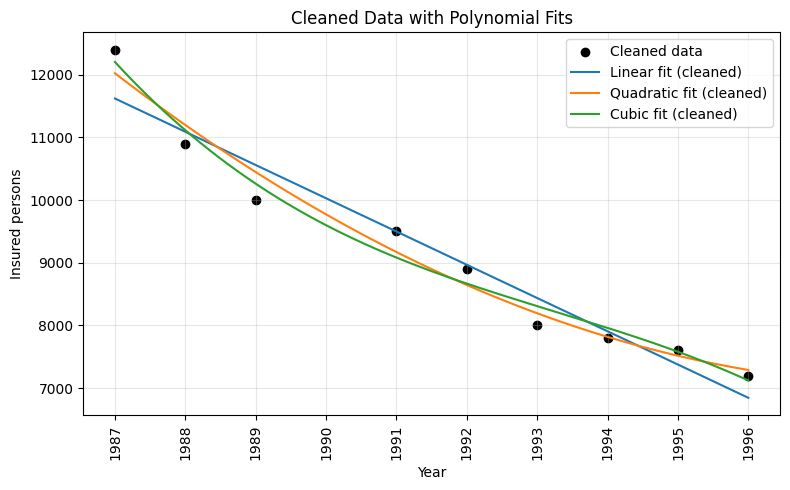

In [ ]:
xx = np.linspace(0, 9, 200)
xx_years = 1987 + xx

plt.figure(figsize=(8, 5))
plt.scatter(years_clean, y_clean, color='black', label='Cleaned data')
plt.plot(xx_years, p_lin_c(xx), label='Linear fit (cleaned)')
plt.plot(xx_years, p_quad_c(xx), label='Quadratic fit (cleaned)')
plt.plot(xx_years, p_cubic_c(xx), label='Cubic fit (cleaned)')
plt.title('Cleaned Data with Polynomial Fits')
plt.xlabel('Year')
plt.ylabel('Insured persons')
plt.xticks(years, rotation='vertical')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Cleaned Data with Fits.png')
plt.show()
plt.close()

## Select best cleaned model and predict for 1997

In [ ]:
# Select the cleaned model with the highest R^2, but favor simpler models unless improvement is substantial
# Use a threshold for R^2 improvement to avoid overfitting with higher-degree polynomials
r2_threshold = 0.05  # Minimum improvement in R^2 to justify adding a parameter

best_clean_model_name = 'linear'  # Start with simplest model

if clean_r2['quadratic'] - clean_r2['linear'] > r2_threshold:
    best_clean_model_name = 'quadratic'
    if clean_r2['cubic'] - clean_r2['quadratic'] > r2_threshold:
        best_clean_model_name = 'cubic'

best_clean_models = {
    'linear': p_lin_c,
    'quadratic': p_quad_c,
    'cubic': p_cubic_c,
}
best_clean_model = best_clean_models[best_clean_model_name]

# Predict the insured persons in year 1997 -> x = 10 relative to 1987
x_pred_1997 = 10
y_pred_1997 = best_clean_model(x_pred_1997)

print(f'Best cleaned model: {best_clean_model_name.capitalize()}')
print(f'Prediction for 1997 (x = {x_pred_1997}): {y_pred_1997:.0f} insured persons')

# The fitted model objects and metrics remain available in the notebook namespace for further exploration.

Best cleaned model: Linear
Prediction for 1997 (x = 10): 6313 insured persons


# 2. Regression analysis of heating oil usage based on temperature and insulation

This notebook fits linear and quadratic regression models to the heating oil dataset, compares fit quality using $R^2$, removes outliers, and then refits the models to the cleaned data before making a prediction for specific conditions.

## Load data and define metrics

In [ ]:
# Heating oil data: oil (gallons?), temp (F), insulation (inches)
oil = np.array([270, 362, 162, 45, 91, 233, 372, 305, 234, 122, 25, 210, 450, 325, 52])
temp = np.array([40, 27, 40, 73, 65, 65, 10, 9, 24, 65, 66, 41, 22, 40, 60])
ins = np.array([4, 4, 10, 6, 7, 40, 6, 10, 10, 4, 10, 6, 4, 4, 10])

# r2_score is already defined above

## Fit linear and quadratic models to the original dataset

In [ ]:
# Fit linear model: oil = a + b*temp + c*ins
X_lin = np.column_stack([np.ones(len(oil)), temp, ins])
coeff_lin = np.linalg.lstsq(X_lin, oil, rcond=None)[0]
y_pred_lin = X_lin @ coeff_lin
r2_lin_orig = r2_score(oil, y_pred_lin)

# Fit quadratic model: oil = a + b*temp + c*ins + d*temp^2 + e*ins^2 + f*temp*ins
X_quad = np.column_stack([np.ones(len(oil)), temp, ins, temp**2, ins**2, temp*ins])
coeff_quad = np.linalg.lstsq(X_quad, oil, rcond=None)[0]
y_pred_quad = X_quad @ coeff_quad
r2_quad_orig = r2_score(oil, y_pred_quad)

original_r2_oil = {
    'linear': r2_lin_orig,
    'quadratic': r2_quad_orig,
}

print('Original model R^2 values:')
for name, value in original_r2_oil.items():
    print(f'  {name.capitalize():9s}: {value:.4f}')

Original model R^2 values:
  Linear   : 0.6967
  Quadratic: 0.9742


## Remove the outlier and refit on cleaned data

In [ ]:
# Remove the outlier: insulation = 40 inches (much higher than others)
mask_oil = ins < 20
oil_clean = oil[mask_oil]
temp_clean = temp[mask_oil]
ins_clean = ins[mask_oil]

# Refit linear model to cleaned data
X_lin_c = np.column_stack([np.ones(len(oil_clean)), temp_clean, ins_clean])
coeff_lin_c = np.linalg.lstsq(X_lin_c, oil_clean, rcond=None)[0]
y_pred_lin_c = X_lin_c @ coeff_lin_c
r2_lin_clean = r2_score(oil_clean, y_pred_lin_c)

# Refit quadratic model to cleaned data
X_quad_c = np.column_stack([np.ones(len(oil_clean)), temp_clean, ins_clean, temp_clean**2, ins_clean**2, temp_clean*ins_clean])
coeff_quad_c = np.linalg.lstsq(X_quad_c, oil_clean, rcond=None)[0]
y_pred_quad_c = X_quad_c @ coeff_quad_c
r2_quad_clean = r2_score(oil_clean, y_pred_quad_c)

clean_r2_oil = {
    'linear': r2_lin_clean,
    'quadratic': r2_quad_clean,
}

print('Cleaned model R^2 values:')
for name, value in clean_r2_oil.items():
    print(f'  {name.capitalize():9s}: {value:.4f}')

Cleaned model R^2 values:
  Linear   : 0.9606
  Quadratic: 0.9769


## Select best cleaned model and predict for given conditions

In [ ]:
# Select the cleaned model with the highest R^2, favoring simpler models unless improvement is substantial
r2_threshold_oil = 0.05  # Minimum improvement in R^2 to justify adding parameters

best_clean_model_name_oil = 'linear'  # Start with simplest model

if clean_r2_oil['quadratic'] - clean_r2_oil['linear'] > r2_threshold_oil:
    best_clean_model_name_oil = 'quadratic'

# Define prediction functions for cleaned models
def predict_lin_clean(temp, ins):
    return coeff_lin_c[0] + coeff_lin_c[1] * temp + coeff_lin_c[2] * ins

def predict_quad_clean(temp, ins):
    return (coeff_quad_c[0] + coeff_quad_c[1] * temp + coeff_quad_c[2] * ins +
            coeff_quad_c[3] * temp**2 + coeff_quad_c[4] * ins**2 + coeff_quad_c[5] * temp * ins)

# Predict for temp=15 F, ins=5 inches
temp_pred = 15
ins_pred = 5

if best_clean_model_name_oil == 'linear':
    oil_pred = predict_lin_clean(temp_pred, ins_pred)
else:
    oil_pred = predict_quad_clean(temp_pred, ins_pred)

print(f'Best cleaned model: {best_clean_model_name_oil.capitalize()}')
print(f'Prediction for temp={temp_pred} F, ins={ins_pred} inches: {oil_pred:.0f} gallons')

# The fitted model coefficients and metrics remain available in the notebook namespace for further exploration.

Best cleaned model: Linear
Prediction for temp=15 F, ins=5 inches: 403 gallons
